In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('D:\Dharmik\Data Scientist(Course)\projects\ML\Retail_brain_ai\data\online_retail_II.csv')

In [3]:
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   Invoice      1067371 non-null  object 
 1   StockCode    1067371 non-null  object 
 2   Description  1062989 non-null  object 
 3   Quantity     1067371 non-null  int64  
 4   InvoiceDate  1067371 non-null  object 
 5   Price        1067371 non-null  float64
 6   Customer ID  824364 non-null   float64
 7   Country      1067371 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 65.1+ MB


In [5]:
print((df.isnull().sum() / len(df) * 100))

Invoice         0.000000
StockCode       0.000000
Description     0.410541
Quantity        0.000000
InvoiceDate     0.000000
Price           0.000000
Customer ID    22.766873
Country         0.000000
dtype: float64


In [6]:
df_clean = df.dropna(subset=['Customer ID'])

In [7]:
df_clean

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom
...,...,...,...,...,...,...,...,...
1067366,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
1067367,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
1067368,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France
1067369,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,2011-12-09 12:50:00,4.95,12680.0,France


In [8]:
df_clean.isnull().sum()

Invoice        0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
Price          0
Customer ID    0
Country        0
dtype: int64

In [9]:
df_clean.duplicated().sum()

np.int64(26479)

In [10]:
df_clean = df_clean.drop_duplicates()

In [11]:
print(len(df_clean))
print(len(df))

797885
1067371


In [12]:
refunds = df_clean[df_clean['Quantity'] < 0]
print(f"Total Rufund Transaction: {len(refunds)}")
print(f"Estimated Lost Revenue: ${abs(refunds['Price'] * refunds['Quantity']).sum():,.2f}")

Total Rufund Transaction: 18390
Estimated Lost Revenue: $1,084,812.98


In [13]:
print("Top 10 Countries by Transaction Count")
print(df_clean['Country'].value_counts(normalize=True).head(10) * 100) 

Top 10 Countries by Transaction Count
Country
United Kingdom    89.751656
Germany            2.173120
EIRE               2.007056
France             1.741730
Netherlands        0.643827
Spain              0.470494
Belgium            0.389780
Switzerland        0.383263
Portugal           0.302550
Australia          0.236876
Name: proportion, dtype: float64


In [14]:
print("Top 5 products by Quantity Sold")
print(df_clean.groupby('Description')['Quantity'].sum().nlargest(5))

Top 5 products by Quantity Sold
Description
WORLD WAR 2 GLIDERS ASSTD DESIGNS     103505
WHITE HANGING HEART T-LIGHT HOLDER     88126
ASSORTED COLOUR BIRD ORNAMENT          77755
JUMBO BAG RED RETROSPOT                73033
BROCADE RING PURSE                     69343
Name: Quantity, dtype: int64


In [15]:
df_clean['Revenue'] = df_clean['Quantity'] * df_clean['Price']
df_clean['Revenue']

C:\Users\patel\AppData\Local\Temp\ipykernel_17976\3277697538.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['Revenue'] = df_clean['Quantity'] * df_clean['Price']


0           83.40
1           81.00
2           81.00
3          100.80
4           30.00
            ...  
1067366     12.60
1067367     16.60
1067368     16.60
1067369     14.85
1067370     18.00
Name: Revenue, Length: 797885, dtype: float64

In [16]:
print("Top 5 products by Revenue")
print(df_clean.groupby('Description')['Revenue'].sum().nlargest(5))

Top 5 products by Revenue
Description
REGENCY CAKESTAND 3 TIER              261110.95
WHITE HANGING HEART T-LIGHT HOLDER    237678.61
JUMBO BAG RED RETROSPOT               132180.02
ASSORTED COLOUR BIRD ORNAMENT         123631.87
POSTAGE                               110338.51
Name: Revenue, dtype: float64


In [17]:
df_clean['InvoiceDate'] = pd.to_datetime(df_clean['InvoiceDate'])

C:\Users\patel\AppData\Local\Temp\ipykernel_17976\1990367648.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['InvoiceDate'] = pd.to_datetime(df_clean['InvoiceDate'])


In [18]:
print("Monthly Revenue Summary")
print(df_clean.groupby(df_clean['InvoiceDate'].dt.to_period('M'))['Revenue'].sum())

Monthly Revenue Summary
InvoiceDate
2009-12     660125.100
2010-01     530436.512
2010-02     487596.426
2010-03     633419.311
2010-04     558007.832
2010-05     557873.390
2010-06     568784.550
2010-07     560885.330
2010-08     585259.460
2010-09     778520.051
2010-10     961520.740
2010-11    1129025.162
2010-12     552372.860
2011-01     473731.900
2011-02     435534.070
2011-03     578576.210
2011-04     425222.671
2011-05     647011.670
2011-06     606862.520
2011-07     573112.321
2011-08     615078.090
2011-09     929356.232
2011-10     973306.380
2011-11    1126815.070
2011-12     341557.430
Freq: M, Name: Revenue, dtype: float64


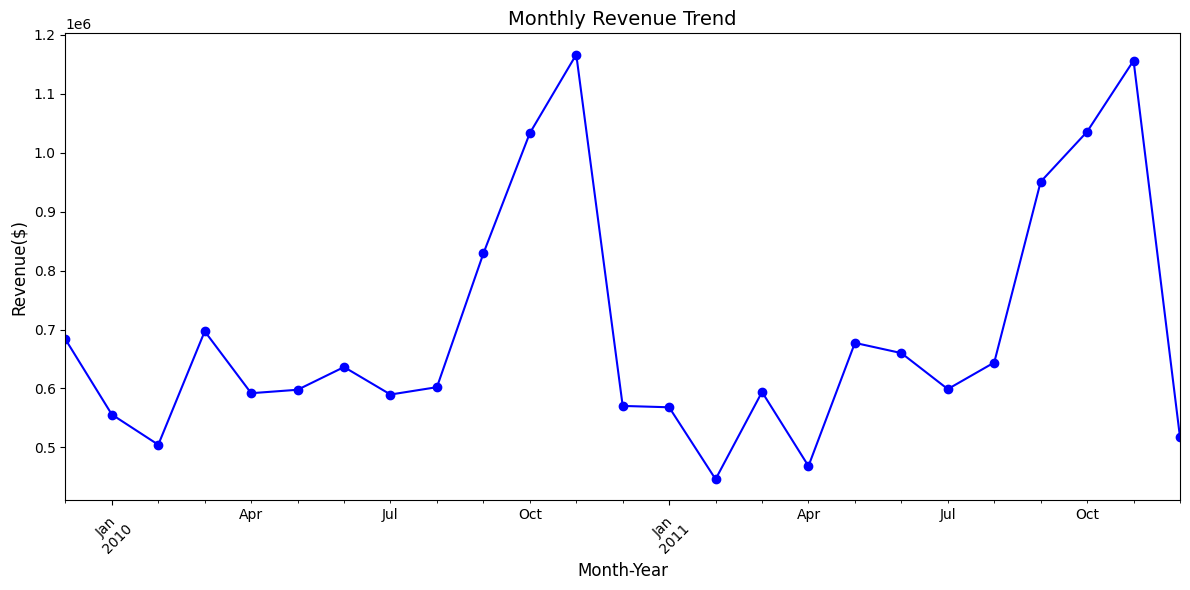

In [19]:
plt.figure(figsize=(12, 6))

sales_data = df_clean[df_clean['Quantity'] > 0]
monthly_revenue = sales_data.groupby(sales_data['InvoiceDate'].dt.to_period('M'))['Revenue'].sum()

monthly_revenue.plot(kind='line', marker= 'o', color= 'b')
plt.title('Monthly Revenue Trend', fontsize=14)
plt.xlabel('Month-Year', fontsize=12)
plt.ylabel('Revenue($)', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

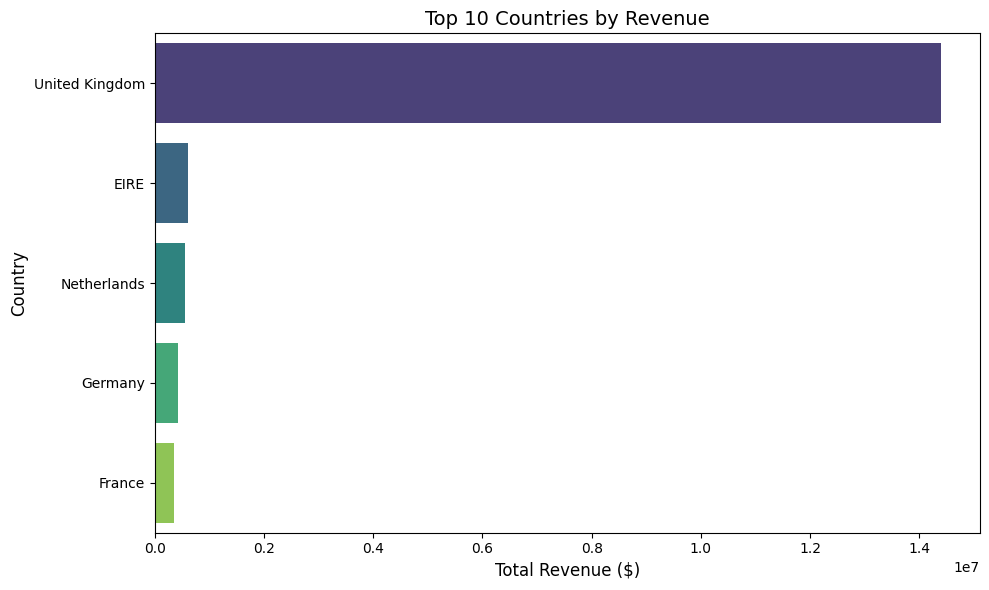

In [20]:
plt.figure(figsize=(10, 6))

top_countries = sales_data.groupby('Country')['Revenue'].sum().nlargest(5)

sns.barplot(x=top_countries.values, y=top_countries.index, palette = 'viridis', hue=top_countries.index, legend= False)
plt.title('Top 10 Countries by Revenue', fontsize = 14)
plt.xlabel('Total Revenue ($)', fontsize = 12)
plt.ylabel('Country', fontsize = 12)
plt.tight_layout()
plt.show()

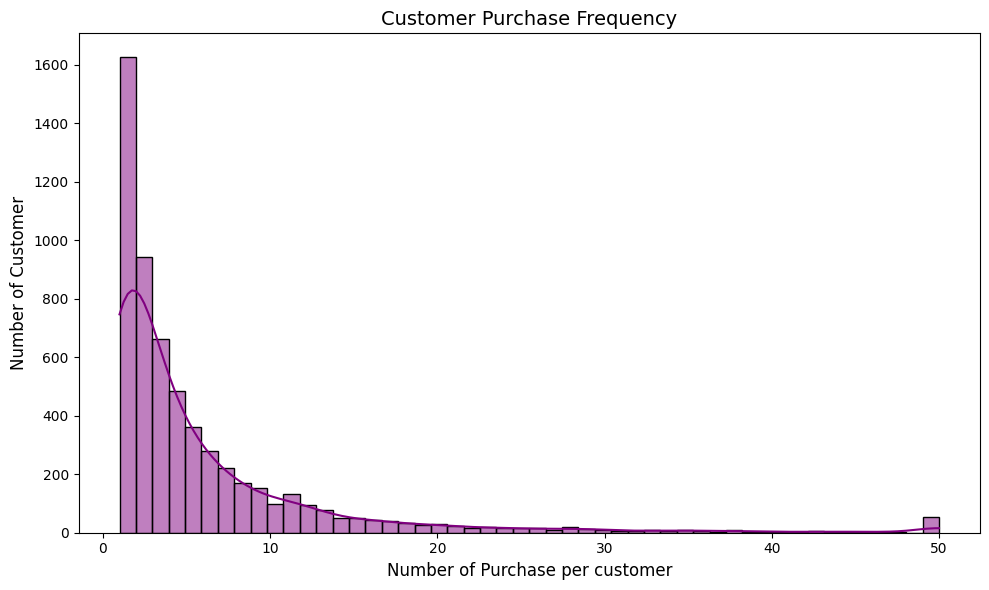

In [21]:
plt.figure(figsize=(10, 6))

purchase_freq = sales_data.groupby('Customer ID')['Invoice'].nunique()

sns.histplot(purchase_freq.clip(upper=50), bins=50, kde=True, color= 'purple')
plt.title('Customer Purchase Frequency', fontsize = 14)
plt.xlabel('Number of Purchase per customer', fontsize =12)
plt.ylabel('Number of Customer', fontsize =12)
plt.tight_layout()
plt.show()

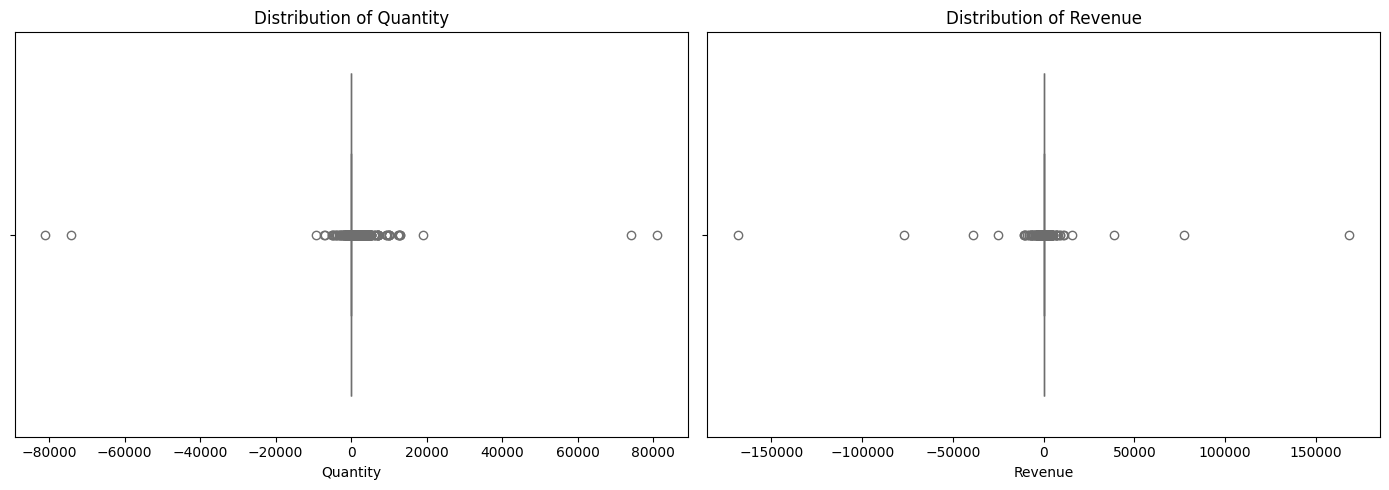

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(x = df_clean['Quantity'], ax = axes[0], color = 'skyblue')
axes[0].set_title('Distribution of Quantity')
axes[0].set_xlabel('Quantity')

sns.boxplot(x=df_clean['Revenue'], ax=axes[1], color='salmon')
axes[1].set_title('Distribution of Revenue')
axes[1].set_xlabel('Revenue')

plt.tight_layout()
plt.show()

In [23]:
df_clean.columns

Index(['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'Price', 'Customer ID', 'Country', 'Revenue'],
      dtype='object')

### RFM

In [24]:
df_clean_rf = df_clean[df_clean['Quantity'] > 0] 

In [25]:
snapshot_date = df_clean_rf['InvoiceDate'].max() + pd.Timedelta(days=1)

In [26]:
snapshot_date

Timestamp('2011-12-10 12:50:00')

In [27]:
recency = df_clean_rf.groupby('Customer ID')['InvoiceDate'].max().reset_index()

recency.columns = ['Customer ID','LastPurchaseDate']

recency['Recency'] = ( snapshot_date - recency['LastPurchaseDate']).dt.days

In [28]:
recency

,Customer ID,LastPurchaseDate,Recency
0,12346.0,2011-01-18 10:01:00,326
1,12347.0,2011-12-07 15:52:00,2
2,12348.0,2011-09-25 13:13:00,75
3,12349.0,2011-11-21 09:51:00,19
4,12350.0,2011-02-02 16:01:00,310
...,...,...,...
5876,18283.0,2011-12-06 12:02:00,4
5877,18284.0,2010-10-04 11:33:00,432
5878,18285.0,2010-02-17 10:24:00,661
5879,18286.0,2010-08-20 11:57:00,477


In [29]:
frequency = df_clean_rf.groupby('Customer ID')['Invoice'].nunique().reset_index()

In [30]:
frequency

,Customer ID,Invoice
0,12346.0,12
1,12347.0,8
2,12348.0,5
3,12349.0,4
4,12350.0,1
...,...,...
5876,18283.0,22
5877,18284.0,1
5878,18285.0,1
5879,18286.0,2


In [31]:
monetary = df_clean_rf.groupby('Customer ID')['Revenue'].sum().reset_index()

In [32]:
monetary

,Customer ID,Revenue
0,12346.0,77556.46
1,12347.0,4921.53
2,12348.0,2019.40
3,12349.0,4428.69
4,12350.0,334.40
...,...,...
5876,18283.0,2664.90
5877,18284.0,461.68
5878,18285.0,427.00
5879,18286.0,1296.43


In [33]:
rfm = recency[['Customer ID','Recency']].merge(frequency,on='Customer ID').merge(monetary,on='Customer ID')
rfm.head()

,Customer ID,Recency,Invoice,Revenue
0,12346.0,326,12,77556.46
1,12347.0,2,8,4921.53
2,12348.0,75,5,2019.40
3,12349.0,19,4,4428.69
4,12350.0,310,1,334.40


### AvgOrderValue

In [34]:
invoice_value = df_clean_rf.groupby(['Customer ID','Invoice'])['Revenue'].sum().reset_index()
invoice_value.head()

,Customer ID,Invoice,Revenue
0,12346.0,491725,45.0
1,12346.0,491742,22.5
2,12346.0,491744,22.5
3,12346.0,492718,22.5
4,12346.0,492722,1.0


In [108]:
avg_order = invoice_value.groupby('Customer ID')['Revenue'].mean().reset_index()
avg_order.head()

,Customer ID,Revenue
0,12346.0,6463.038333
1,12347.0,615.191250
2,12348.0,403.880000
3,12349.0,1107.172500
4,12350.0,334.400000


In [109]:
avg_order.columns = ['CustomerID','AvgOrderValue']

In [110]:
avg_order

,CustomerID,AvgOrderValue
0,12346.0,6463.038333
1,12347.0,615.191250
2,12348.0,403.880000
3,12349.0,1107.172500
4,12350.0,334.400000
...,...,...
5876,18283.0,121.131818
5877,18284.0,461.680000
5878,18285.0,427.000000
5879,18286.0,648.215000


### UniqueProducts

In [38]:
df_clean_rf.columns

Index(['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'Price', 'Customer ID', 'Country', 'Revenue'],
      dtype='object')

In [70]:
unique_products = df_clean_rf.groupby('Customer ID')['StockCode'].nunique().reset_index()
unique_products.columns = ['CustomerID','UniqueProducts']
unique_products

,CustomerID,UniqueProducts
0,12346.0,27
1,12347.0,126
2,12348.0,25
3,12349.0,138
4,12350.0,17
...,...,...
5876,18283.0,352
5877,18284.0,28
5878,18285.0,12
5879,18286.0,67


### PurchaseInterval

In [52]:
purchase_dates = df_clean_rf.groupby(['Customer ID', 'Invoice'])['InvoiceDate'].min().reset_index()
purchase_dates

,Customer ID,Invoice,InvoiceDate
0,12346.0,491725,2009-12-14 08:34:00
1,12346.0,491742,2009-12-14 11:00:00
2,12346.0,491744,2009-12-14 11:02:00
3,12346.0,492718,2009-12-18 10:47:00
4,12346.0,492722,2009-12-18 10:55:00
...,...,...,...
36970,18287.0,523290,2010-09-21 12:19:00
36971,18287.0,534346,2010-11-22 11:51:00
36972,18287.0,554065,2011-05-22 10:39:00
36973,18287.0,570715,2011-10-12 10:23:00


In [63]:
purchase_dates['DaysDiff'] = purchase_dates.groupby('Customer ID')['InvoiceDate'].diff().dt.days
purchase_dates

,Customer ID,Invoice,InvoiceDate,DaysDiff
0,12346.0,491725,2009-12-14 08:34:00,NaN
1,12346.0,491742,2009-12-14 11:00:00,0.0
2,12346.0,491744,2009-12-14 11:02:00,0.0
3,12346.0,492718,2009-12-18 10:47:00,3.0
4,12346.0,492722,2009-12-18 10:55:00,0.0
...,...,...,...,...
36970,18287.0,523290,2010-09-21 12:19:00,0.0
36971,18287.0,534346,2010-11-22 11:51:00,61.0
36972,18287.0,554065,2011-05-22 10:39:00,180.0
36973,18287.0,570715,2011-10-12 10:23:00,142.0


In [105]:
purchase_interval = purchase_dates.groupby('Customer ID')['DaysDiff'].mean().reset_index()

purchase_interval.columns = ['CustomerID','PurchaseInterval']
purchase_interval

,CustomerID,PurchaseInterval
0,12346.0,35.909091
1,12347.0,57.000000
2,12348.0,90.500000
3,12349.0,189.666667
4,12350.0,NaN
...,...,...
5876,18283.0,30.666667
5877,18284.0,NaN
5878,18285.0,NaN
5879,18286.0,247.000000


### Average products per invoice

In [99]:
basket = df_clean_rf.groupby(['Customer ID','Invoice'])['Quantity'].sum().reset_index()

basket_size = basket.groupby('Customer ID')['Quantity'].mean().reset_index()

basket_size.columns = ['CustomerID','BasketSize']

### Country Diversity

In [73]:
country_diversity = df.groupby('Customer ID')['Country'].nunique().reset_index()

country_diversity.columns = ['CustomerID','CountryDiversity']

In [78]:
country_diversity['CountryDiversity'].unique()

array([1, 2])

In [116]:
rfm = rfm.rename(columns={'Customer ID' : 'CustomerID'})

In [117]:
rfm = rfm.merge(avg_order,
                on='CustomerID',
                how='left')

rfm = rfm.merge(unique_products,
                on='CustomerID',
                how='left')

rfm = rfm.merge(purchase_interval,
                on='CustomerID',
                how='left')

rfm = rfm.merge(basket_size,
                on='CustomerID',
                how='left')

rfm = rfm.merge(country_diversity,
                on='CustomerID',
                how='left')

In [119]:
rfm.drop(columns=['AvgOrderValue_x'],inplace=True)

In [121]:
rfm = rfm.rename(columns={'AvgOrderValue_y' : 'AvgOrderValue'})

In [122]:
rfm

,CustomerID,Recency,Invoice,Revenue,AvgOrderValue,UniqueProducts,PurchaseInterval,BasketSize,CountryDiversity
0,12346.0,326,12,77556.46,6463.038333,27,35.909091,6190.416667,1
1,12347.0,2,8,4921.53,615.191250,126,57.000000,370.875000,1
2,12348.0,75,5,2019.40,403.880000,25,90.500000,542.800000,1
3,12349.0,19,4,4428.69,1107.172500,138,189.666667,406.000000,1
4,12350.0,310,1,334.40,334.400000,17,NaN,197.000000,1
...,...,...,...,...,...,...,...,...,...
5876,18283.0,4,22,2664.90,121.131818,352,30.666667,76.318182,1
5877,18284.0,432,1,461.68,461.680000,28,NaN,494.000000,1
5878,18285.0,661,1,427.00,427.000000,12,NaN,145.000000,1
5879,18286.0,477,2,1296.43,648.215000,67,247.000000,304.000000,1


In [123]:
rfm.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5881 entries, 0 to 5880
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   CustomerID        5881 non-null   float64
 1   Recency           5881 non-null   int64  
 2   Invoice           5881 non-null   int64  
 3   Revenue           5881 non-null   float64
 4   AvgOrderValue     5881 non-null   float64
 5   UniqueProducts    5881 non-null   int64  
 6   PurchaseInterval  4255 non-null   float64
 7   BasketSize        5881 non-null   float64
 8   CountryDiversity  5881 non-null   int64  
dtypes: float64(5), int64(4)
memory usage: 413.6 KB


In [126]:
rfm.rename(columns={'Invoice': 'Frequency','Revenue': 'Monetary'}, inplace=True)

In [ ]:
rfm['PurchaseInterval'] = rfm['PurchaseInterval'].fillna(0)

In [127]:
rfm.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5881 entries, 0 to 5880
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   CustomerID        5881 non-null   float64
 1   Recency           5881 non-null   int64  
 2   Frequency         5881 non-null   int64  
 3   Monetary          5881 non-null   float64
 4   AvgOrderValue     5881 non-null   float64
 5   UniqueProducts    5881 non-null   int64  
 6   PurchaseInterval  5881 non-null   float64
 7   BasketSize        5881 non-null   float64
 8   CountryDiversity  5881 non-null   int64  
dtypes: float64(5), int64(4)
memory usage: 413.6 KB


In [128]:
rfm.head()

,CustomerID,Recency,Frequency,Monetary,AvgOrderValue,UniqueProducts,PurchaseInterval,BasketSize,CountryDiversity
0,12346.0,326,12,77556.46,6463.038333,27,35.909091,6190.416667,1
1,12347.0,2,8,4921.53,615.191250,126,57.000000,370.875000,1
2,12348.0,75,5,2019.40,403.880000,25,90.500000,542.800000,1
3,12349.0,19,4,4428.69,1107.172500,138,189.666667,406.000000,1
4,12350.0,310,1,334.40,334.400000,17,0.000000,197.000000,1


In [131]:
rfm.to_csv('D:\Dharmik\Data Scientist(Course)\projects\ML\Retail_brain_ai\data\customer_df.csv',index=False)